This notebook is for the analysis of question 3 in the survey - how well explained is the response?

In [67]:
"""
This script loads in responses from classification csv file output by Zooniverse,
and normalizes them into a table with one row per task answered
"""
import json
import logging
import sqlite3
from pathlib import Path
from datetime import datetime
import seaborn as sns

import pandas as pd
import matplotlib.pyplot as plt

# PARAMETERS
classifications_csv_path = 'survey_responses/may-survey-classifications_2025-06-17.csv'
output_dir = 'survey_responses/analysis/may'
ml_responses_database_path = 'records_bedrock.db'
subjects_path = 'survey_responses/review-llm-responses-on-lca-tasks-subjects.csv'
workflow_id = 28845

In [68]:
import seaborn as sns
sns.set_theme(style="darkgrid")
# Wrap x-tick labels and rotate
def wrap_labels(ax, width, break_long_words=True):
    xlabels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        parts = text.split('-')
        wrapped_parts = [textwrap.fill(part, width=width, break_long_words=break_long_words) for part in parts]
        wrapped_text = ' '.join(wrapped_parts)
        xlabels.append(wrapped_text)
    ax.set_xticks(ax.get_xticks())  # Set ticks explicitly
    ax.set_xticklabels(xlabels, rotation=45, ha='right')
    ylabels=[]
    for label in ax.get_yticklabels():
        text = label.get_text()
        ylabels.append(textwrap.fill(text, width=width, break_long_words=break_long_words))
    ax.set_yticks(ax.get_yticks())  # Set ticks explicitly
    ax.set_yticklabels(ylabels, rotation=45, ha='right')

# Load data

In [69]:
current_date = datetime.now().strftime('%Y%m%d')

logging.basicConfig(level=logging.INFO)

# Read classifications
classifications_df = pd.read_csv(classifications_csv_path)
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

subjects_df = pd.read_csv(subjects_path)
# Extract the prompt_id, llm model and other data from the metadata column
subjects_df = subjects_df.loc[subjects_df.workflow_id==workflow_id]
metadata_df = subjects_df['metadata'].apply(json.loads).apply(pd.Series)
subjects_df = pd.concat([subjects_df, metadata_df], axis=1)

# TODO: Prompts and responses in one database
# TODO: filter out questions that were withdrawn
prompts_database_path = 'records_cajetan.db'
conn = sqlite3.connect(prompts_database_path)
prompts_df = pd.read_sql('''select * from prompts''', conn)
ml_responses_database_path = 'records_may_all.db'
conn = sqlite3.connect(ml_responses_database_path)
ml_responses_df = pd.read_sql('select * from responses', conn)


In [70]:
from analyze_responses_q1 import get_count_completed_tasks

# Count complete answers
classifications_df[['count_completed_tasks', 'final_completed_task_no']] = classifications_df.annotations.apply(
    get_count_completed_tasks)
print('Count completed tasks (note some tasks are optional)')
print(classifications_df.count_completed_tasks.value_counts())
print('Final completed task number')
print(classifications_df.final_completed_task_no.value_counts())


Count completed tasks (note some tasks are optional)
count_completed_tasks
6     138
7      41
8      18
9      15
10      9
Name: count, dtype: int64
Final completed task number
final_completed_task_no
8     205
9      10
10      6
Name: count, dtype: int64


In [71]:
from analyze_responses_q1 import explode_tasks

# Combine with the subject data, to get the llm name, the prompt text, etc
# Explode the annotations column
exploded_dfs = classifications_df['annotations'].apply(explode_tasks)
exploded_df = pd.concat(exploded_dfs.values, keys=exploded_dfs.index,
                        names=['original_index', 'task_index']).reset_index(level='task_index', drop=True)
# Pivot the DataFrame to have one column per task
pivoted_df = exploded_df.pivot(columns='task', values='value').reset_index()
# Re-insert the classification_ids
pivoted_df['subject_id'] = classifications_df.loc[pivoted_df['original_index'], 'subject_ids'].values
# Merge and set dtype of prompt_id
combined_df = pivoted_df.merge(subjects_df,on='subject_id',how='inner')
combined_df.prompt_id = combined_df.prompt_id.astype(int)

# Merge with prompts
combined_final = combined_df.merge(prompts_df, on='prompt_id')

# Check if the number of rows in the merged dataframe differs from the number of rows in the left dataframe
if combined_final.shape[0] != combined_df.shape[0]:
    logging.error(
        f"The number of rows in the merged dataframe ({combined_final.shape[0]}) when merging combined_df on prompts_df differs from the number of rows in the left dataframe ({combined_df.shape[0]}).")
    exit()

In [72]:
combined_final.value_counts(subset=['prompt_id','prompt_text'])

prompt_id  prompt_text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

# Analyse Q3

In [73]:
summary_q3 = combined_final.T3.value_counts()

In [74]:
summary_q3

T3
3 - good                          114
2 - average                        56
1 - poor                           30
4 - expert / better than human     19
Name: count, dtype: int64

In [75]:
# map t2 to numerical values
rating_description_to_number = {"3 - good": 3,
"2 - average": 2,
"1 - poor": 1,
"4 - expert / better than human": 4}

In [76]:
combined_final['T2_score']=combined_final['T2'].apply(lambda x: rating_description_to_number[x])

In [77]:
combined_final.columns

Index(['original_index', 'T1', 'T10', 'T11', 'T12', 'T2', 'T3', 'T4', 'T6',
       'T7', 'T8', 'T9', 'subject_id', 'project_id', 'workflow_id',
       'subject_set_id', 'metadata', 'locations', 'classifications_count',
       'retired_at', 'retirement_reason', 'created_at', 'updated_at',
       '#date_run', 'prompt_id', '#llm_model', 'response_id', '#temperature',
       '#llm_provider', '#prompt_run_by', 'prompt_text', 'T2_score'],
      dtype='object')

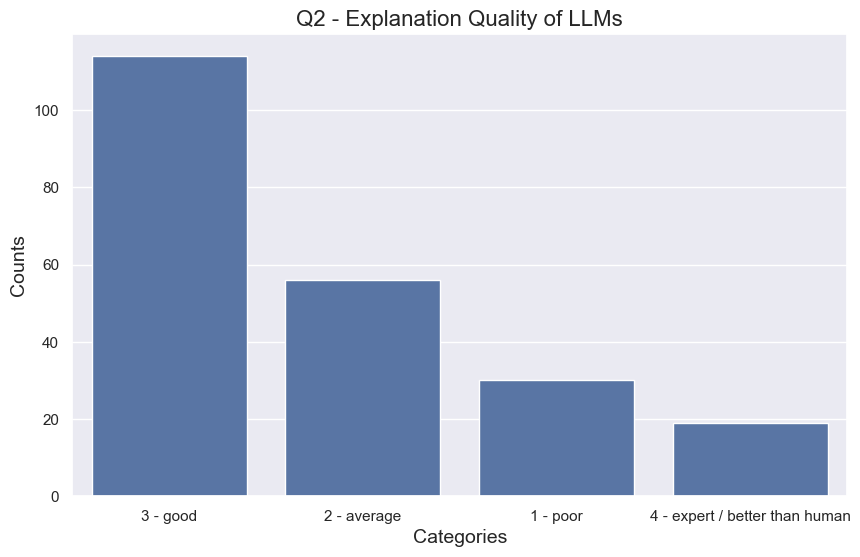

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=summary_q3.index, y=summary_q3.values)
plt.title('Q2 - Explanation Quality of LLMs',fontsize=16)
plt.xlabel('Categories',fontsize=14)
plt.ylabel('Counts',fontsize=14)
plt.show()

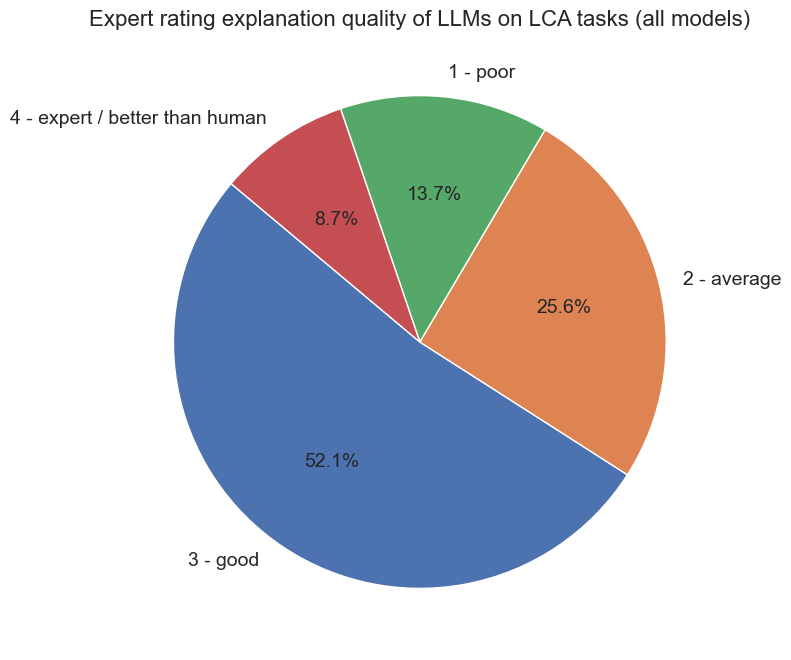

In [79]:
# Pie Chart with larger text
plt.figure(figsize=(8, 8))
plt.pie(summary_q3.values, labels=summary_q3.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 14})
plt.title('Expert rating explanation quality of LLMs on LCA tasks (all models)', fontsize=16)
plt.show()

In [80]:
q2_by_model = combined_final.groupby(['#llm_model', 'T2_score']).size().unstack(fill_value=0)

In [81]:
q2_by_model

T2_score,1,2,3,4
#llm_model,,,,
gemini/gemini-2.0-flash-001,1,4,4,4
mistral/mistral-large-2411,4,6,10,0
ollama_chat/deepseek-r1:8b,8,8,7,0
ollama_chat/gemma3:27b,3,2,5,0
ollama_chat/phi4:latest,3,4,10,0
ollama_chat/qwen3:30b,4,6,5,5
openai/gpt-4.1,0,6,17,2
us.amazon.nova-premier-v1:0,2,5,9,2
us.anthropic.claude-3-7-sonnet-20250219-v1:0,4,4,8,0


In [82]:
model_t2_mean = combined_final.groupby('#llm_model')['T2_score'].mean().sort_values(ascending=False)
print(model_t2_mean)


#llm_model
gemini/gemini-2.0-flash-001                     2.846154
openai/gpt-4.1                                  2.840000
us.amazon.nova-premier-v1:0                     2.611111
us.meta.llama4-scout-17b-instruct-v1:0          2.571429
ollama_chat/qwen3:30b                           2.550000
us.meta.llama4-maverick-17b-instruct-v1:0       2.421053
ollama_chat/phi4:latest                         2.411765
us.deepseek.r1-v1:0                             2.333333
mistral/mistral-large-2411                      2.300000
us.anthropic.claude-3-7-sonnet-20250219-v1:0    2.250000
ollama_chat/gemma3:27b                          2.200000
ollama_chat/deepseek-r1:8b                      1.956522
Name: T2_score, dtype: float64


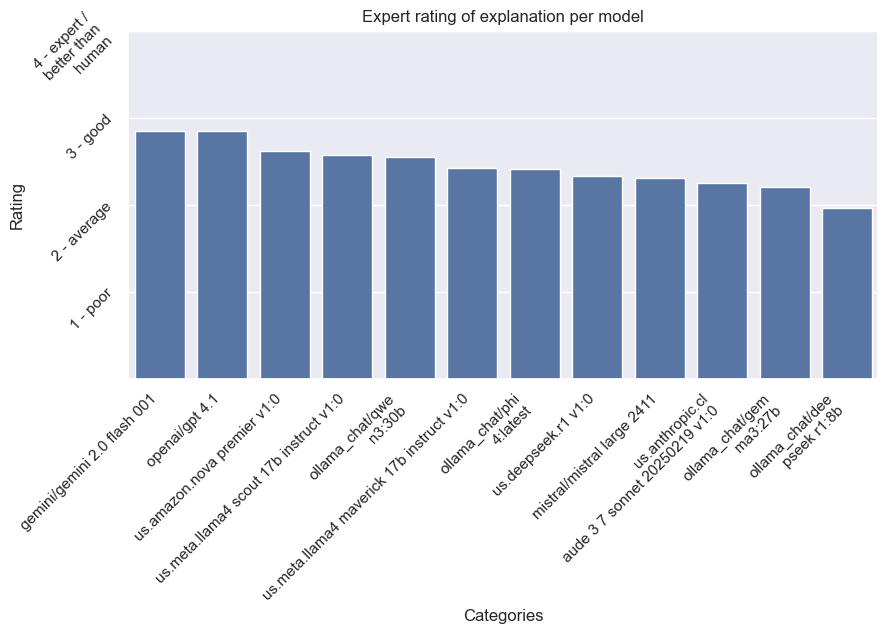

In [83]:



# Count Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=model_t2_mean.index,y=model_t2_mean.values)
plt.title('Expert rating of explanation per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(list(rating_description_to_number.values()), list(rating_description_to_number.keys()))


plt.subplots_adjust(left=0.15, bottom=0.3)
wrap_labels(plt.gca(), width=15)

plt.savefig(output_dir/f'{current_date}_q2_scientific_explanation_per_model.png')
plt.show()



# The same, but take the median

In [84]:
model_t2_median = combined_final.groupby('#llm_model')['T2_score'].median().sort_values(ascending=False)
print(model_t2_mean)


#llm_model
gemini/gemini-2.0-flash-001                     2.846154
openai/gpt-4.1                                  2.840000
us.amazon.nova-premier-v1:0                     2.611111
us.meta.llama4-scout-17b-instruct-v1:0          2.571429
ollama_chat/qwen3:30b                           2.550000
us.meta.llama4-maverick-17b-instruct-v1:0       2.421053
ollama_chat/phi4:latest                         2.411765
us.deepseek.r1-v1:0                             2.333333
mistral/mistral-large-2411                      2.300000
us.anthropic.claude-3-7-sonnet-20250219-v1:0    2.250000
ollama_chat/gemma3:27b                          2.200000
ollama_chat/deepseek-r1:8b                      1.956522
Name: T2_score, dtype: float64


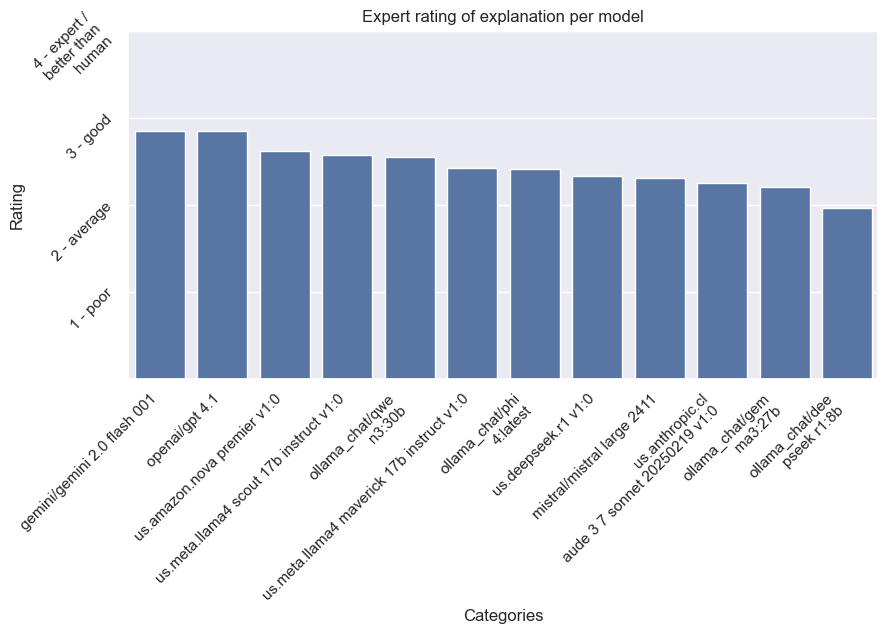

In [85]:
import textwrap
sns.set_theme(style="darkgrid")

# Count Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=model_t2_mean.index,y=model_t2_mean.values)
plt.title('Expert rating of explanation per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(list(rating_description_to_number.values()), list(rating_description_to_number.keys()))


plt.subplots_adjust(left=0.15, bottom=0.3)
wrap_labels(plt.gca(), width=15)

plt.savefig(output_dir/f'{current_date}_q2_scientific_explanation_per_model_median.png')
plt.show()



# Violin plot

In [86]:
# Add count of datapoints per model to combined_df
counts_per_model = combined_final.groupby('#llm_model').T2.agg(len).to_dict()

combined_final['data_points_per_model'] = combined_final['#llm_model'].apply(lambda x: counts_per_model[x])

C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 32.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarnin

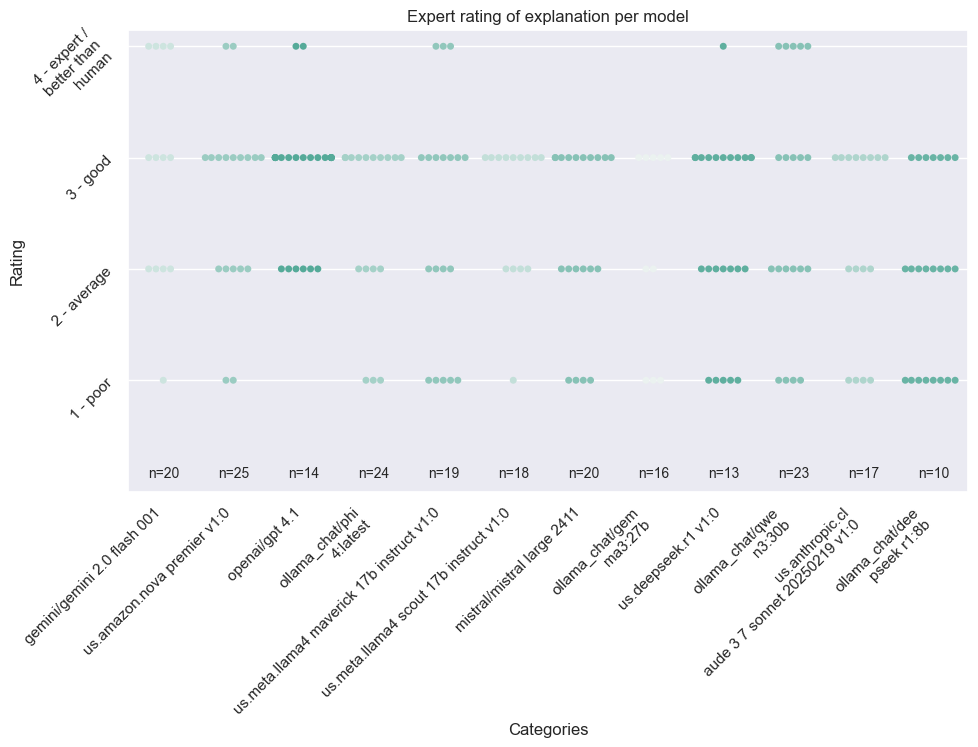

In [87]:
import numpy as np

def convert_dict_to_sorted_list(input_dict):
    # Sort the keys based on their values
    sorted_keys = sorted(input_dict, key=input_dict.get)
    return sorted_keys
ylabels_text = convert_dict_to_sorted_list(rating_description_to_number)
ylabels_text.insert(0,'')
# Violin Plot

plt.figure(figsize=(12, 6))

colors = sns.color_palette("light:#5A9", as_cmap=True)

ax = sns.swarmplot(x='#llm_model', y='T2_score', data=combined_final,order=list(model_t2_median.index),hue='data_points_per_model',palette=colors)
plt.title('Expert rating of explanation per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(np.arange(0,5,1), ylabels_text)

# Rotate x-tick labels and adjust alignment
plt.xticks(rotation=45, ha='right')
wrap_labels(plt.gca(), width=15)


# Add number of data points to each bar
for i, model in enumerate(combined_final['#llm_model'].unique()):
    count = combined_final[combined_final['#llm_model'] == model]['T2_score'].count()
    ax.text(i, ax.get_ylim()[0] + 0.1, f'n={count}', ha='center', va='bottom', fontsize=10)

ax.get_legend().remove()
plt.subplots_adjust(left=0.15, right=0.85)
plt.savefig(output_dir/f'{current_date}_q2_scientific_explanation_per_model_violin.png')

plt.show()

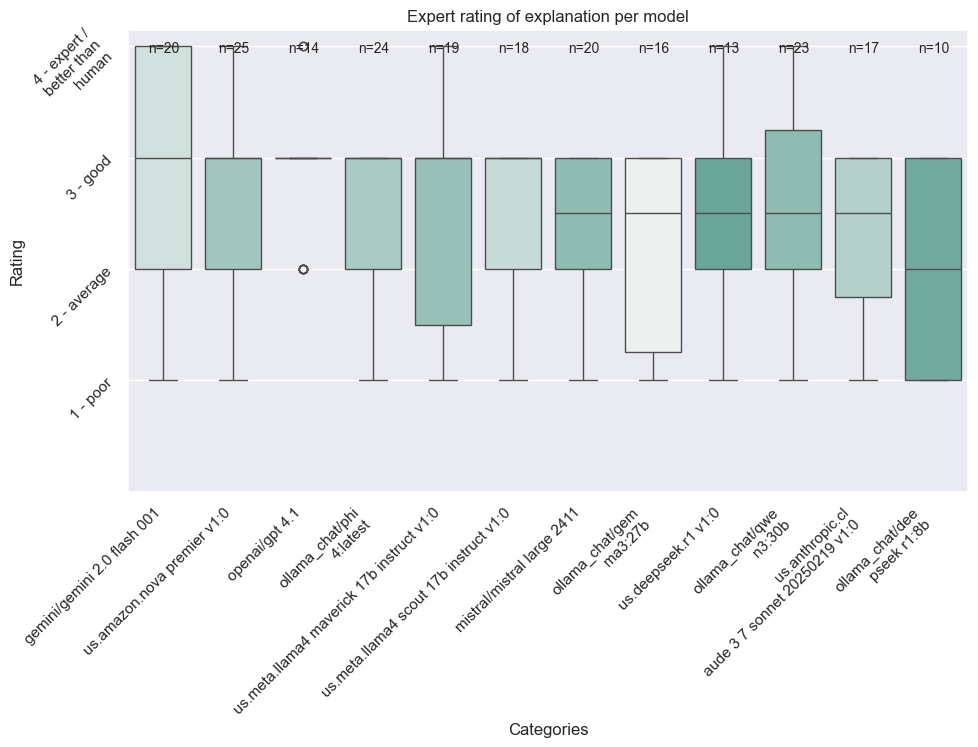

In [88]:
import numpy as np

def convert_dict_to_sorted_list(input_dict):
    # Sort the keys based on their values
    sorted_keys = sorted(input_dict, key=input_dict.get)
    return sorted_keys

ylabels_text = convert_dict_to_sorted_list(rating_description_to_number)
ylabels_text.insert(0, '')

# Whisker Plot
plt.figure(figsize=(12, 6))

colors = sns.color_palette("light:#5A9", as_cmap=True)

ax = sns.boxplot(x='#llm_model', y='T2_score', data=combined_final, order=list(model_t2_median.index), hue='data_points_per_model', palette=colors)
plt.title('Expert rating of explanation per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(np.arange(0, 5, 1), ylabels_text)

# Rotate x-tick labels and adjust alignment
plt.xticks(rotation=45, ha='right')
wrap_labels(plt.gca(), width=15)

# Add number of data points to each bar
for i, model in enumerate(combined_final['#llm_model'].unique()):
    count = combined_final[combined_final['#llm_model'] == model]['T2_score'].count()
    ax.text(i, ax.get_ylim()[1] - 0.1, f'n={count}', ha='center', va='top', fontsize=10)

ax.get_legend().remove()
plt.subplots_adjust(left=0.15, right=0.85)
plt.savefig(output_dir / f'{current_date}_q2_scientific_explanation_per_model_whisker.png')

plt.show()

In [89]:
ylabels_text

['', '1 - poor', '2 - average', '3 - good', '4 - expert / better than human']

# Analyse textual remarks in comment field for Q3

In [92]:
combined_final.T8.drop_duplicates()

0                                      Clear explanation
1                                                       
7      well explained, but it could have been explain...
8      There seems to be a missing part between page ...
9      General infromation is provided, but limited i...
10                       Answer is justified very poorly
12     misses reference to allocation hierachy and IS...
13     The answer is correct and skematic in does not...
14     the answer is detailed and correct even though...
17                  The answer is exhaustive and correct
18                    the answer is not well articulated
19     There are significant missing details. Also be...
20     The answer contains all the information requir...
21                         The answer lacks in synthesis
22     The explanation is someway general without any...
23                 The reasoning is clear in interesting
24     Very good response analysing the difference be...
25                The answer is

In [110]:

from wordcloud import  WordCloud
import multidict
import re

def get_frequency_dict_for_text(sentence):
    fullTermsDict = multidict.MultiDict()
    tmpDict = {}

    # making dict for counting frequencies
    for text in sentence.split(" "):
        if re.match("a|the|an|the|to|in|for|of|or|by|with|is|on|that|be|answer|response|but|not|it|\.|,", text):
            continue
        val = tmpDict.get(text, 0)
        tmpDict[text.lower()] = val + 1
    for key in tmpDict:
        fullTermsDict.add(key, tmpDict[key])
    return fullTermsDict



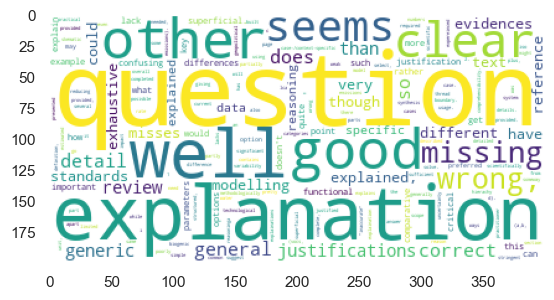

In [111]:
# Join all answers to get a single piece of text
all_answers_text=' '.join(combined_final.T8.drop_duplicates().to_list())

# Custom frequencies calculation
all_answers_frequencies = get_frequency_dict_for_text(all_answers_text)

# Create wordcloud
wordcloud_obj = WordCloud(background_color="white")
wordcloud_obj.generate_from_frequencies(all_answers_frequencies)

plt.grid(visible=False,which='both',axis='both')
plt.imshow(wordcloud_obj)
plt.show()

In [98]:
plt.show()

In [139]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()
q3_extra_comments = combined_final.loc[:,'T8'].drop_duplicates()
q3_extra_comments = pd.DataFrame({'response_id':q3_extra_comments.index,'comment':q3_extra_comments.values})

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Artur\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [175]:
get_sentiment_nltk_vader = lambda x: sia.polarity_scores(x)['compound']
q3_extra_comments['sentiment_vader_simple'] = q3_extra_comments.comment.dropna().map(get_sentiment_nltk_vader)

In [176]:
q3_extra_comments

,index,comment,sentiment,sentiment_flair,sentiment_flair_label,sentiment_flair_confidence,sentiment_vader_simple
0,0.0,Clear explanation,0.3818,"(POSITIVE, 0.9994818568229675)",POSITIVE,0.999482,0.3818
1,1.0,,0.0000,"(O, 1.0)",O,1.000000,0.0000
2,7.0,"well explained, but it could have been explain...",0.1406,"(NEGATIVE, 0.7077109217643738)",NEGATIVE,0.707711,0.1406
3,8.0,There seems to be a missing part between page ...,-0.6486,"(NEGATIVE, 0.9985533356666565)",NEGATIVE,0.998553,-0.6486
4,9.0,"General infromation is provided, but limited i...",-0.3291,"(NEGATIVE, 0.9992351531982422)",NEGATIVE,0.999235,-0.3291
5,10.0,Answer is justified very poorly,0.4019,"(NEGATIVE, 0.9980156421661377)",NEGATIVE,0.998016,0.4019
6,12.0,misses reference to allocation hierachy and IS...,-0.2263,"(NEGATIVE, 0.9994227886199951)",NEGATIVE,0.999423,-0.2263
7,13.0,The answer is correct and skematic in does not...,0.0000,"(NEGATIVE, 0.9996260404586792)",NEGATIVE,0.999626,0.0000
8,14.0,the answer is detailed and correct even though...,-0.4404,"(POSITIVE, 0.999257504940033)",POSITIVE,0.999258,-0.4404
9,17.0,The answer is exhaustive and correct,-0.1280,"(POSITIVE, 0.9969543218612671)",POSITIVE,0.996954,-0.1280


In [191]:
# Sentiment using FLAIR https://github.com/flairNLP/flair
# Flair gives better quality sentiment analyses on this type of dataset than VADER, as it is trained on longer-form movie reviews whereas NLTK's VADER is trained on short-form informal social media posts
from flair.data import Sentence
from flair.nn import Classifier

# load the NER tagger
tagger = Classifier.load('sentiment')


['annotation_layers', '_embeddings', '_metadata', 'tokens', '_known_spans', 'language_code', '_start_position', 'tokenized', 'is_document_boundary', '_previous_sentence', '_has_context', '_next_sentence', '_position_in_dataset', '__module__', '__doc__', '__init__', 'unlabeled_identifier', 'get_relations', 'get_spans', 'get_token', '_add_token', 'embedding', 'to', 'clear_embeddings', 'left_context', 'right_context', '__str__', 'to_tagged_string', 'text', 'to_tokenized_string', 'to_plain_string', 'infer_space_after', 'to_original_text', 'to_dict', 'get_span', '__getitem__', '__iter__', '__len__', '__repr__', 'start_position', 'end_position', 'get_language_code', '_handle_problem_characters', '_Sentence__remove_zero_width_characters', '_Sentence__restore_windows_1252_characters', 'next_sentence', 'previous_sentence', 'is_context_set', 'copy_context_from_sentence', 'set_context_for_sentences', 'get_labels', 'remove_labels', 'set_embedding', 'get_embedding', 'get_each_embedding', 'has_label

In [193]:
def get_sentiment_flair(x, tagger):
    sentence = Sentence(x)
    tagger.predict(sentence)
    return pd.Series([sentence.get_label().value, sentence.get_label().score])
q3_extra_comments[['sentiment_flair_label','sentiment_flair_confidence']] = q3_extra_comments.comment.dropna().apply(get_sentiment_flair,tagger=tagger)

2025-06-18 11:42:02,710 Warning: An empty Sentence was created! Are there empty strings in your dataset?


In [180]:
q3_extra_comments

,index,comment,sentiment,sentiment_flair,sentiment_flair_label,sentiment_flair_confidence,sentiment_vader_simple
0,0.0,Clear explanation,0.3818,"(POSITIVE, 0.9994818568229675)",POSITIVE,0.999482,0.3818
1,1.0,,0.0000,"(O, 1.0)",O,1.000000,0.0000
2,7.0,"well explained, but it could have been explain...",0.1406,"(NEGATIVE, 0.7077109217643738)",NEGATIVE,0.707711,0.1406
3,8.0,There seems to be a missing part between page ...,-0.6486,"(NEGATIVE, 0.9985533356666565)",NEGATIVE,0.998553,-0.6486
4,9.0,"General infromation is provided, but limited i...",-0.3291,"(NEGATIVE, 0.9992351531982422)",NEGATIVE,0.999235,-0.3291
5,10.0,Answer is justified very poorly,0.4019,"(NEGATIVE, 0.9980156421661377)",NEGATIVE,0.998016,0.4019
6,12.0,misses reference to allocation hierachy and IS...,-0.2263,"(NEGATIVE, 0.9994227886199951)",NEGATIVE,0.999423,-0.2263
7,13.0,The answer is correct and skematic in does not...,0.0000,"(NEGATIVE, 0.9996260404586792)",NEGATIVE,0.999626,0.0000
8,14.0,the answer is detailed and correct even though...,-0.4404,"(POSITIVE, 0.999257504940033)",POSITIVE,0.999258,-0.4404
9,17.0,The answer is exhaustive and correct,-0.1280,"(POSITIVE, 0.9969543218612671)",POSITIVE,0.996954,-0.1280


In [181]:
sns. q3_extra_comments.sentiment_flair_label

0            POSITIVE
1                   O
2            NEGATIVE
3            NEGATIVE
4            NEGATIVE
5            NEGATIVE
6            NEGATIVE
7            NEGATIVE
8            POSITIVE
9            POSITIVE
10           NEGATIVE
11           NEGATIVE
12           NEGATIVE
13           NEGATIVE
14           NEGATIVE
15           POSITIVE
16           POSITIVE
17           POSITIVE
18           POSITIVE
19           NEGATIVE
20           NEGATIVE
21           NEGATIVE
22           NEGATIVE
23           NEGATIVE
24           NEGATIVE
25           NEGATIVE
26           POSITIVE
27           NEGATIVE
28           NEGATIVE
29           NEGATIVE
30           NEGATIVE
31           POSITIVE
32           NEGATIVE
33           POSITIVE
34           NEGATIVE
35           NEGATIVE
36           NEGATIVE
37           NEGATIVE
38           NEGATIVE
39           NEGATIVE
40           POSITIVE
41           NEGATIVE
42           NEGATIVE
43           NEGATIVE
44           NEGATIVE
45        

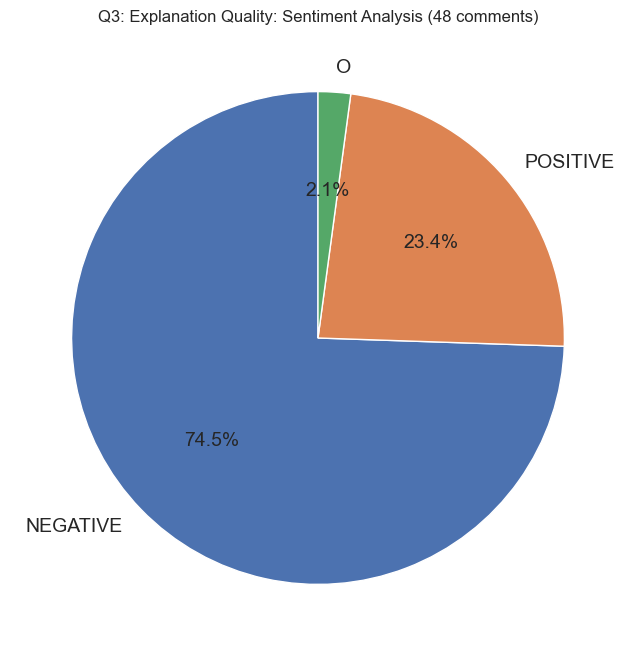

In [190]:
plt.figure(figsize=(8, 8))
sentiment_pivot = q3_extra_comments.sentiment_flair_label.value_counts()
plt.pie(sentiment_pivot, labels=sentiment_pivot.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 14})
plt.title(f'Q3: Explanation Quality: Sentiment Analysis ({q3_extra_comments.shape[0]} comments)')
plt.show()